In [2]:
# ============================================================
# CREDIT CARD FRAUD DETECTION - MACHINE LEARNING
# ============================================================
# Author: Vicente Sánchez Reza
# Date: May 2026
# Description: ML model to detect fraudulent credit card
# transactions using an highly imbalanced dataset.
# ============================================================

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'Times New Roman'
os.makedirs('outputs', exist_ok=True)

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


In [4]:
df = pd.read_csv(r'C:\Users\vicen\Desktop\fraude\creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFraud distribution:")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.3f}%")

Dataset shape: (284807, 31)

Column names: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Fraud distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.173%


In [5]:
# head() muestra las primeras filas
# describe() muestra estadísticas básicas
# isnull().sum() cuenta valores nulos

print(df.head())
print(df.describe())
print(df.isnull().sum())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

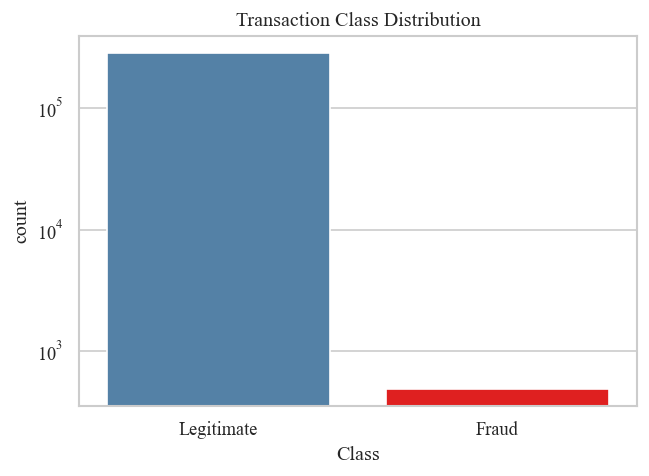

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, hue='Class', palette=['steelblue', 'red'], legend=False)
plt.title('Transaction Class Distribution')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.yscale('log')  # escala logarítmica
plt.savefig('outputs/01_class_distribution.png')
plt.show()

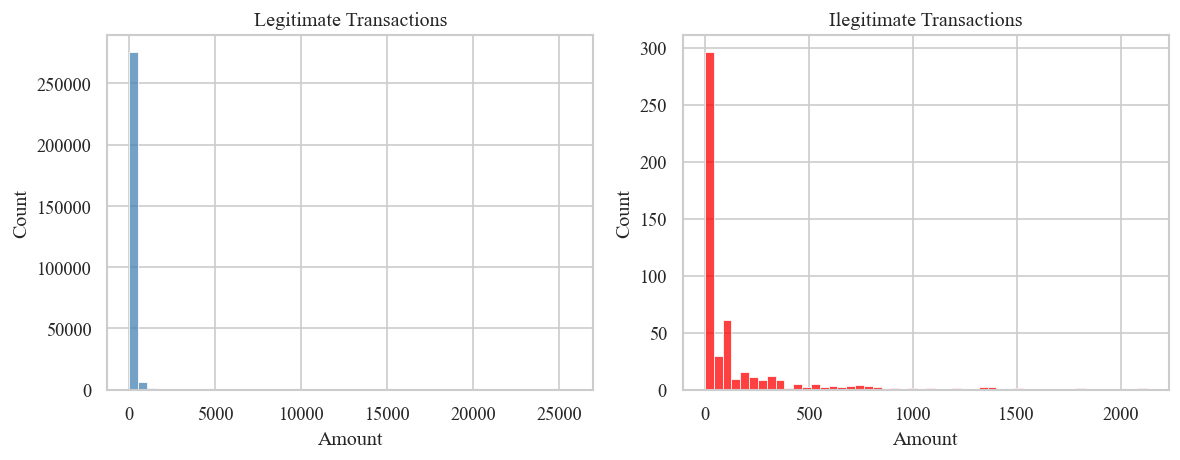

In [7]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data=df[df['Class']==0], x='Amount', bins=50, color='steelblue')
plt.title('Legitimate Transactions')

plt.subplot(1,2,2)
sns.histplot(data=df[df['Class']==1], x='Amount', bins=50, color='red')
plt.title('Ilegitimate Transactions')

plt.tight_layout()
plt.savefig('outputs/02_amount_distribution.png')
plt.show()

In [8]:
X = df.drop('Class', axis=1)
y = df['Class']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (284807, 30)
y shape: (284807,)


In [9]:
# We use train_test_split to separate between train and split. Giving 0.2 = 20% data for the test and 80% for the training
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples:  {len(X_test):,}")

Training samples: 227,845
Testing samples:  56,962


In [10]:
# ── NORMALIZACIÓN DE DATOS ────────────────────────────────────
# Los datos tienen escalas muy diferentes:
# - Amount: entre 0 y 25.000
# - Time: entre 0 y 172.000
# - V1-V28: entre -5 y 5
# StandardScaler convierte todo a media=0 y desviación=1
# Solo escalamos X (features), nunca y (labels 0/1)

scaler = StandardScaler()

# fit_transform en training: aprende la escala Y transforma
X_train_scaled = scaler.fit_transform(X_train)

# transform en test: solo transforma usando la escala aprendida
# NUNCA fit en test para evitar data leakage
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully ✅")

Data scaled successfully ✅


In [11]:
# ── TRAIN LOGISTIC REGRESSION MODEL ──────────────────────────
# Logistic Regression is a simple but effective classification model

# 1. Create the model
model_lr = LogisticRegression(max_iter=1000, random_state=42)

# 2. Train with training data
model_lr.fit(X_train_scaled, y_train)

# 3. Predict with test data
y_pred_lr = model_lr.predict(X_test_scaled)

print("Model trained successfully ✅")

Model trained successfully ✅


In [12]:
# ── MODEL EVALUATION ─────────────────────────────────────────
# We use multiple metrics because accuracy alone is misleading
# with imbalanced datasets

print("=== LOGISTIC REGRESSION RESULTS ===\n")
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_lr):.4f}")

=== LOGISTIC REGRESSION RESULTS ===

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.85      0.56      0.67        98

    accuracy                           1.00     56962
   macro avg       0.92      0.78      0.84     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.7805


In [14]:
# ── TRAIN RANDOM FOREST MODEL ──────────────────────────
# Random Forest builds 100 decision trees and combines them
# Usually performs better than Logistic Regression on complex data
# n_estimators=100 means 100 trees

# 1. Create the model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train with training data
model_rf.fit(X_train_scaled, y_train)

# 3. Predict with test data
y_pred_rf = model_rf.predict(X_test_scaled)

print("Model trained successfully ✅")

Model trained successfully ✅


In [16]:
# ── MODEL EVALUATION ─────────────────────────────────────────

print("=== RANDOM FOREST RESULTS ===\n")
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_rf):.4f}")

=== RANDOM FOREST RESULTS ===

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.97      0.77      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.8826


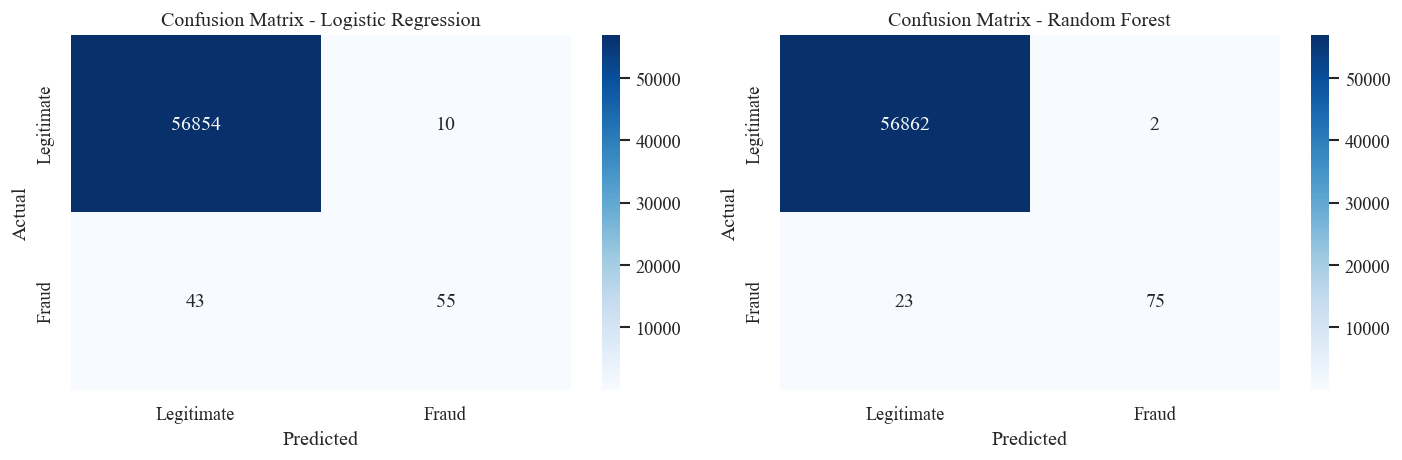

In [17]:
# ── CONFUSION MATRIX ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(axes, 
                              [y_pred_lr, y_pred_rf],
                              ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    ax.set_title(f'Confusion Matrix - {title}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('outputs/03_confusion_matrix.png')
plt.show()

In [18]:
# ── KEY FINDINGS ─────────────────────────────────────────────
print("""
KEY FINDINGS
============

1. DATASET: 284,807 transactions, only 492 fraudulent (0.17%)
   Highly imbalanced dataset — accuracy alone is misleading.

2. AMOUNT: Fraudulent transactions tend to have lower amounts
   compared to legitimate ones (max 2,000 vs 25,000 euros).

3. LOGISTIC REGRESSION:
   - Detects 56% of frauds (recall)
   - 85% precision when flagging fraud
   - Misses 43 fraudulent transactions

4. RANDOM FOREST:
   - Detects 77% of frauds (recall)
   - 97% precision when flagging fraud
   - Only 2 false alarms

5. CONCLUSION: Random Forest outperforms Logistic Regression
   in all metrics, especially recall (56% vs 77%)
""")


KEY FINDINGS

1. DATASET: 284,807 transactions, only 492 fraudulent (0.17%)
   Highly imbalanced dataset — accuracy alone is misleading.

2. AMOUNT: Fraudulent transactions tend to have lower amounts
   compared to legitimate ones (max 2,000 vs 25,000 euros).

3. LOGISTIC REGRESSION:
   - Detects 56% of frauds (recall)
   - 85% precision when flagging fraud
   - Misses 43 fraudulent transactions

4. RANDOM FOREST:
   - Detects 77% of frauds (recall)
   - 97% precision when flagging fraud
   - Only 2 false alarms

5. CONCLUSION: Random Forest outperforms Logistic Regression
   in all metrics, especially recall (56% vs 77%)

